In [305]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

steam_df = pd.read_csv('csv_files/games_march2025.csv')

In [306]:
steam_df['negative'].isna().sum()

np.int64(0)

In [307]:
steam_df.loc[steam_df.duplicated()]

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent


In [308]:
steam_drop = ['notes', 'metacritic_url', 'support_url', 'support_email', 'website', 'screenshots', 'movies', 'reviews', 'score_rank', 'discount', 'peak_ccu', 'pct_pos_total', 'detailed_description', 'about_the_game', 'short_description', 'header_image', 'full_audio_languages', 'recommendations', 'packages', 'tags', 'appid']
dropped_df = steam_df.drop(columns= steam_drop)


In [309]:
conn = sqlite3.connect('sql/video_game_db.db')

dropped_df.to_sql('steam_db', conn, if_exists='replace')

89618

In [310]:
print(pd.read_sql("SELECT name, metacritic_score FROM steam_db WHERE metacritic_score > 50 ORDER BY metacritic_score", conn))

                               name  metacritic_score
0         Five Nights at Freddy's 4                51
1                  Swag and Sorcery                51
2                          Daylight                51
3                     Silver Chains                51
4                      Bullet Witch                51
...                             ...               ...
3428                    Cobalt Core                94
3429   Mass Effect 2 (2010) Edition                94
3430      Grand Theft Auto V Legacy                96
3431                Baldur's Gate 3                96
3432  Disco Elysium - The Final Cut                97

[3433 rows x 2 columns]


In [311]:
print(pd.read_sql("SELECT SUM(windows) as windows, SUM(mac) as mac, SUM(linux) as linux FROM steam_db WHERE windows = 1 OR mac = 1 OR linux = 1", conn))

   windows    mac  linux
0    89588  17438  12627


In [312]:
print(pd.read_sql("SELECT name, release_date FROM steam_db", conn))

                                  name release_date
0                     Counter-Strike 2   2012-08-21
1                  PUBG: BATTLEGROUNDS   2017-12-21
2                               Dota 2   2013-07-09
3            Grand Theft Auto V Legacy   2015-04-13
4      Tom Clancy's Rainbow Six® Siege   2015-12-01
...                                ...          ...
89613                      Outrun Them   2024-02-29
89614      Lands of Pharaoh: Episode 1   2020-01-07
89615                       Player One   2019-10-10
89616                       DragonRoad   2025-01-25
89617               Ragtag Adventurers   2018-03-01

[89618 rows x 2 columns]


In [313]:
dropped_df.columns

Index(['name', 'release_date', 'required_age', 'price', 'dlc_count', 'windows',
       'mac', 'linux', 'metacritic_score', 'achievements',
       'supported_languages', 'developers', 'publishers', 'categories',
       'genres', 'user_score', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks',
       'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent'],
      dtype='object')

<Axes: xlabel='name'>

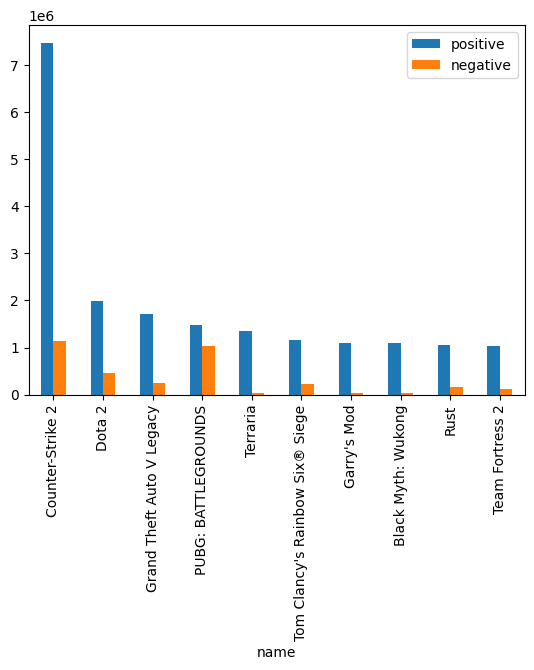

In [325]:
pos_neg = pd.read_sql("SELECT name, positive, negative FROM steam_db ORDER BY positive DESC LIMIT 10", conn)

pos_neg.plot(kind='bar', x='name' )


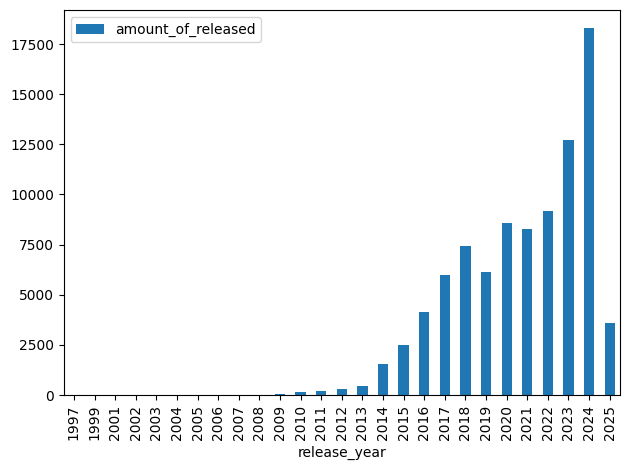

In [315]:
yearly_releases = pd.read_sql("SELECT STRFTIME('%Y', release_date) as release_year,  COUNT(release_date) AS amount_of_released FROM steam_db GROUP BY release_year " , conn)

yearly_releases.plot(kind='bar', x='release_year', y='amount_of_released')

plt.tight_layout()

In [316]:
os_games = pd.read_sql("SELECT  SUM(windows) as windows_games, SUM(mac) as mac_games, SUM(linux) as linux_games FROM steam_db WHERE windows = 1 OR mac = 1 OR linux = 1", conn)


<Axes: xlabel='name'>

c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 20208 (\N{CJK UNIFIED IDEOGRAPH-4EF0}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 26395 (\N{CJK UNIFIED IDEOGRAPH-671B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\PC\Documents\Projects\video_game_sales_analysis\venv\Lib\site-packages\IPython\core\events.py:96: U

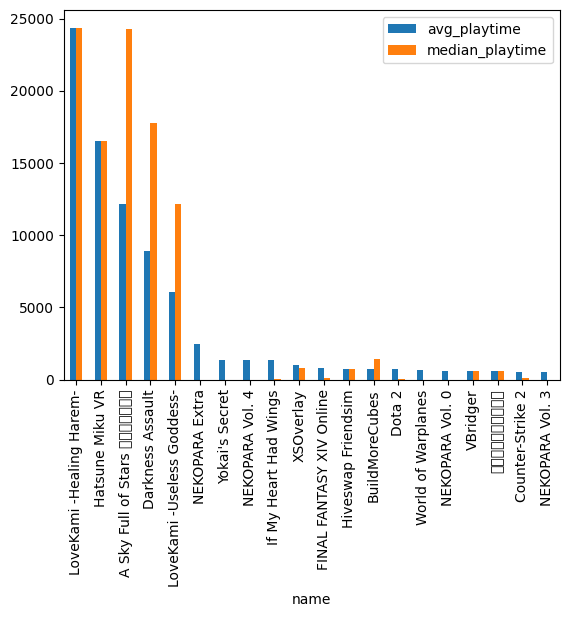

In [317]:
meta_playtime = pd.read_sql("SELECT name, ROUND(average_playtime_forever / 60, 2) AS avg_playtime, ROUND(median_playtime_forever / 60, 2) AS median_playtime FROM steam_db ORDER BY avg_playtime DESC LIMIT 20 ", conn)

meta_playtime.plot(kind='bar', x='name')

In [318]:
# cte_query = """WITH cte AS (
# SELECT name, metacritic_score FROM steam_db WHERE metacritic_score > 50 ORDER BY metacritic_score

# ), user_cte as (

# SELECT name, user_score FROM steam_db WHERE user_score > 50 ORDER BY user_score
# )

# SELECT cte.name, user_cte.user_score, cte.metacritic_score FROM cte
# FULL OUTER JOIN user_cte ON cte.name = user_cte.name
# WHERE user_cte.user_score IS NOT NULL OR cte.metacritic_score IS NOT NULL
# """

# steam_ratings = pd.read_sql("SELECT name, metacritic_score FROM steam_db WHERE metacritic_score IS NOT 0 ", conn)

# steam_ratings.plot(kind='scatter', x='name', y='metacritic_score')